In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_df = pd.read_parquet('train_final.parquet')
test_df = pd.read_parquet('test_final.parquet')
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
train_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack
0,80,5169956,8,6,1101,4222,410,0,137.625,185.758628,...,20,0.0,0.0,0,0,0.0,0.0,0,0,4
1,80,229,2,0,12,0,6,6,6.000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,4
2,80,5001928,3,1,12,0,6,0,4.000,3.464102,...,20,0.0,0.0,0,0,0.0,0.0,0,0,4
3,80,5125872,8,7,1659,2514,467,0,207.375,221.278065,...,20,0.0,0.0,0,0,0.0,0.0,0,0,4
4,80,214,2,0,12,0,6,6,6.000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,4


In [3]:
train_df['Attack'].value_counts()

Attack
0    1720966
4     189135
3      29999
6      25501
2       7417
7       1718
1        974
5         23
Name: count, dtype: int64

In [14]:
sample_size = int(0.25 * len(train_df)) # 25% of the original size
sampled_df = train_df.sample(n = sample_size, replace = False, random_state = 42)
sampled_df.shape

(493933, 79)

In [17]:
# Compare means between original (train_df) and sampled dataset
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()

print("Descriptive Statistics Comparison (mean):\n")
print(f"{'Feature':<32}{'Train Dataset':<22}{'Sampled Dataset':<22}{'Variation %'}")
print('-' * 96)

high_variations = []

for col in numeric_cols:
    old = train_df[col].mean()
    new = sampled_df[col].mean()     

    # avoid divide-by-zero mental breakdown
    if old == 0:
        pct = 0
    else:
        pct = abs((new - old) / old) * 100

    if pct > 5:
        high_variations.append((col, pct))

    print(f"{col:<32}{old:<22.6f}{new:<22.6f}{pct:6.2f}%")

# optional: print summary of big deviations
if high_variations:
    print("\nFeatures with >5% variation:\n")
    for col, pct in high_variations:
        print(f"{col:<32}{pct:6.2f}%")


Descriptive Statistics Comparison (mean):

Feature                         Train Dataset         Sampled Dataset       Variation %
------------------------------------------------------------------------------------------------
Destination Port                8712.207356           8704.313619             0.09%
Flow Duration                   17490250.749950       17374242.313468         0.66%
Total Fwd Packets               10.838033             13.029210              20.22%
Total Backward Packets          12.226185             15.219396              24.48%
Total Length of Fwd Packets     579.312426            589.075207              1.69%
Total Length of Bwd Packets     19397.629709          25558.703326           31.76%
Fwd Packet Length Max           204.966813            204.169819              0.39%
Fwd Packet Length Min           18.172665             18.120654               0.29%
Fwd Packet Length Mean          54.307043             54.282829               0.04%
Fwd Packet Lengt

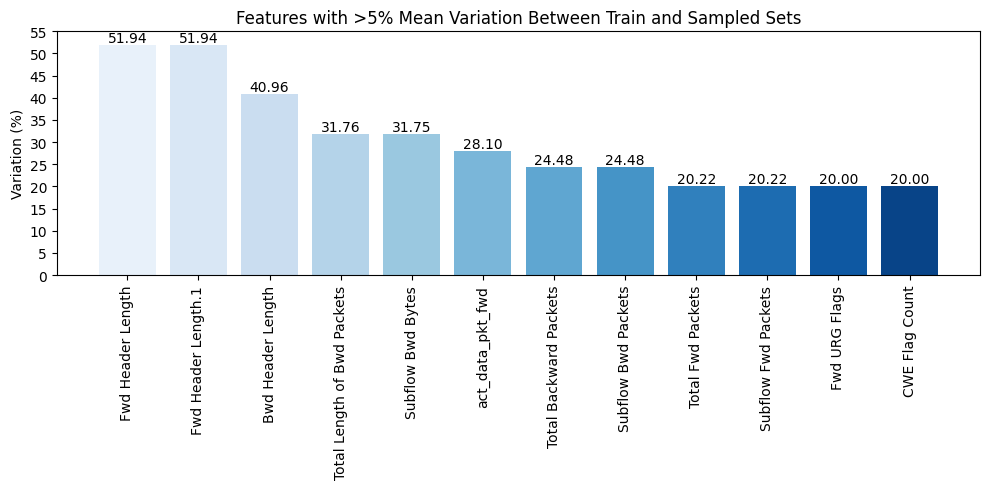

In [16]:
# Sort high_variations by percentage (descending)
high_variations_sorted = sorted(high_variations, key=lambda x: x[1], reverse=True)

# Unpack sorted labels + values
labels  = [t[0] for t in high_variations_sorted]
values  = [t[1] for t in high_variations_sorted]

# Plot
colors = sns.color_palette('Blues', n_colors=len(labels))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(labels, values, color=colors)

# Annotate bars
for i, val in enumerate(values):
    ax.text(i, val, f"{val:.2f}", ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=90)
ax.set_title("Features with >5% Mean Variation Between Train and Sampled Sets")
ax.set_ylabel("Variation (%)")
ax.set_yticks(np.arange(0, max(values) + 5, 5))

plt.tight_layout()
plt.show()


In [ ]:
# Printing the unique value count
indent = '{:<3} {:<30}: {}'
print('Unique value count for: ')
for i, feature in enumerate(list(sampled_df.columns)[:-1], start = 1):
    print(indent.format(f'{i}.', feature, sampled_df[feature].nunique()))

Unique value count for: 
1.  Destination Port              : 32217
2.  Flow Duration                 : 246933
3.  Total Fwd Packets             : 672
4.  Total Backward Packets        : 840
5.  Total Length of Fwd Packets   : 9057
6.  Total Length of Bwd Packets   : 24148
7.  Fwd Packet Length Max         : 3651
8.  Fwd Packet Length Min         : 242
9.  Fwd Packet Length Mean        : 35826
10. Fwd Packet Length Std         : 67425
11. Bwd Packet Length Max         : 3923
12. Bwd Packet Length Min         : 449
13. Bwd Packet Length Mean        : 46521
14. Bwd Packet Length Std         : 64136
15. Flow Bytes/s                  : 337753
16. Flow Packets/s                : 280389
17. Flow IAT Mean                 : 264559
18. Flow IAT Std                  : 218532
19. Flow IAT Max                  : 158367
20. Flow IAT Min                  : 47129
21. Fwd IAT Total                 : 118080
22. Fwd IAT Mean                  : 159944
23. Fwd IAT Std                   : 143341
24. Fwd IAT

In [ ]:
'''Generating a set of visualizations for columns that have more than one unique value but less than 50 unique values.
For categorical columns, a bar plot is generated showing the count of each unique value.
For numerical columns, a histogram is generated.'''
unique_values = sampled_df.nunique()
selected_cols = sampled_df[[col for col in sampled_df if 1 < unique_values[col] < 50]]
rows, cols = selected_cols.shape
col_names = list(selected_cols)
num_of_rows = (cols + 3) // 4

cols

13

ValueError: num must be an integer with 1 <= num <= 8, not 9

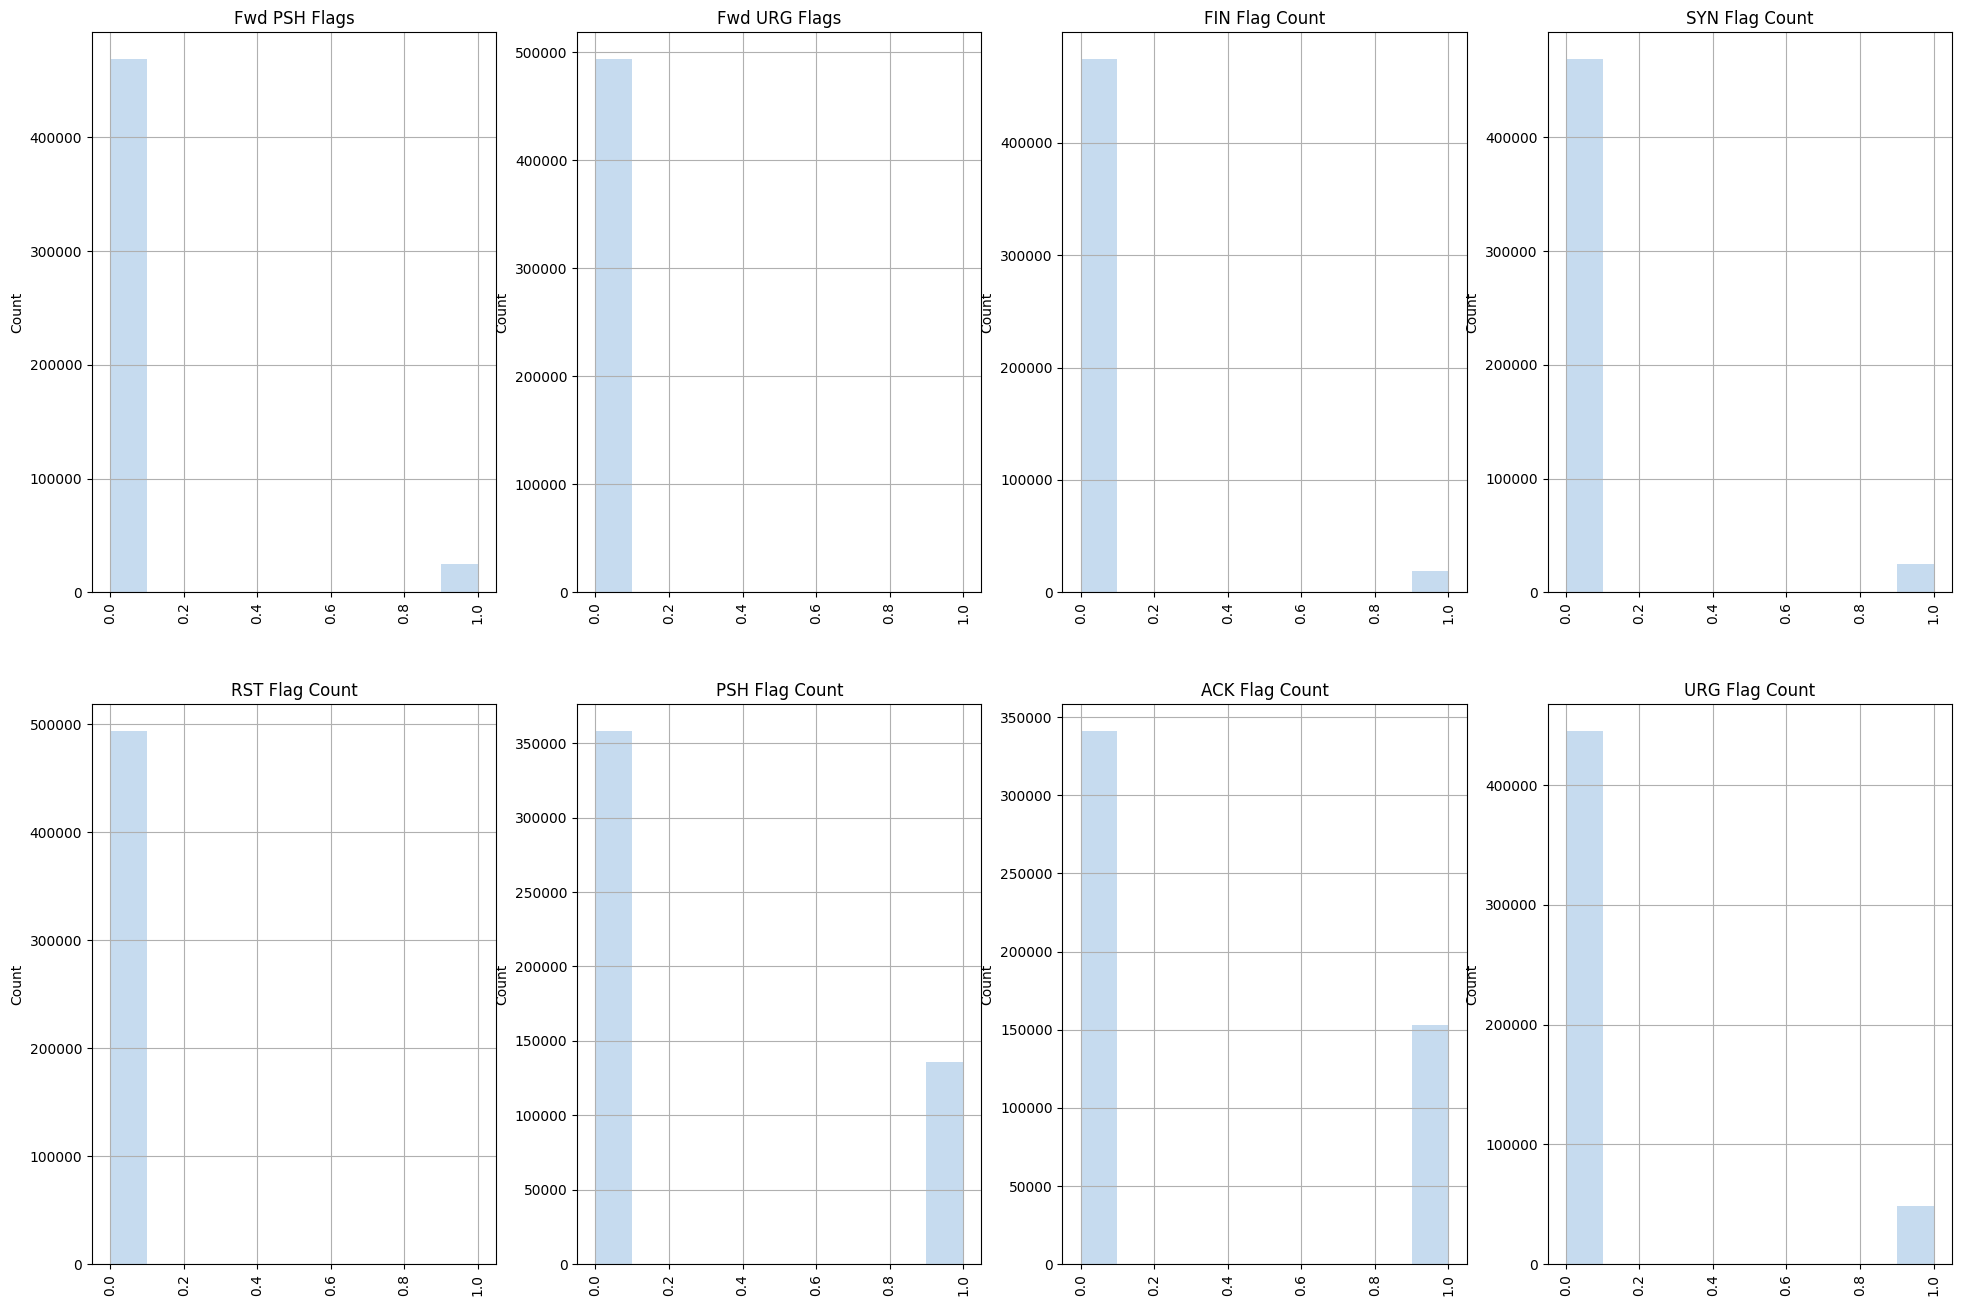

In [26]:
color_palette = sns.color_palette('Blues', n_colors = 3)
plt.figure(figsize = (6 * 4, 8 * num_of_rows))

for i in range(cols):
    plt.subplot(num_of_rows, 4, i + 1)
    col_data = selected_cols.iloc[:, i]
    if col_data.dtype.name == 'object':
        col_data.value_counts().plot(kind = 'bar', color = color_palette[2])
    else:
        col_data.hist(color = color_palette[0])

    plt.ylabel('Count')
    plt.xticks(rotation = 90)
    plt.title(col_names[i])

plt.tight_layout()
plt.show()